<a href="https://colab.research.google.com/github/AngelinaZhm/lab7_iad/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def create_clients_data():
    np.random.seed(42)
    n = 1000
    data = {
        'age': np.random.randint(18, 70, n),
        'income': np.random.randint(10000, 80000, n),
        'gender': np.random.choice(['male', 'female'], n),
        'property': np.random.choice(['yes', 'no'], n),
        'bad_client_target': np.random.choice([0, 1], n, p=[0.7, 0.3])
    }
    pd.DataFrame(data).to_csv('clients_b.csv', index=False)

create_clients_data()

--- Завдання 2: Заголовок таблиці ---
   age  income  gender property  bad_client_target
0   56   44674  female       no                  1
1   69   45854  female      yes                  0
2   46   56271    male       no                  0
3   32   48518    male      yes                  0
4   60   20267  female      yes                  0

3. Формат міток: int64

4. Характеристики після факторизації:
   age  income  gender  property  bad_client_target
0   56   44674       0         0                  1
1   69   45854       0         1                  0
2   46   56271       1         0                  0
3   32   48518       1         1                  0
4   60   20267       0         1                  0

5. Збалансованість класів:
bad_client_target
0    0.697
1    0.303
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



10. Мережу навчено.
11. Якість на тесті: Accuracy = 0.6800


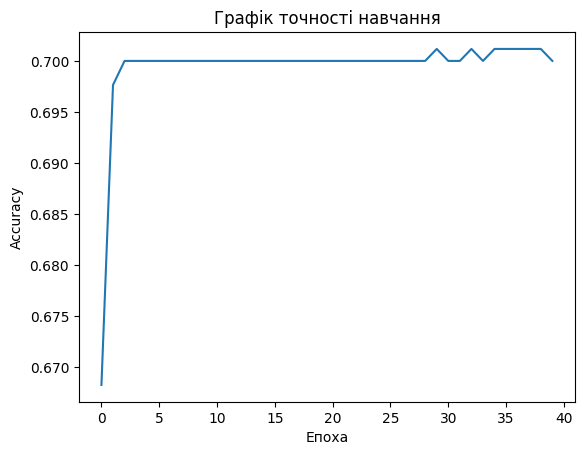

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

13. Результат тестування:
«Передбачено клас Надійний (0) з достовірністю 86.03%»
Дійсний клас: Ненадійний (1)


In [7]:

df = pd.read_csv('clients_b.csv')

print("--- Завдання 2: Заголовок таблиці ---")
print(df.head())

print(f"\n3. Формат міток: {df['bad_client_target'].dtype}")

to_factor = ['gender', 'property']
df[to_factor] = df[to_factor].apply(lambda col: pd.factorize(col, sort=True)[0])
print("\n4. Характеристики після факторизації:")
print(df.head())

print("\n5. Збалансованість класів:")
print(df['bad_client_target'].value_counts(normalize=True))

X = df.drop('bad_client_target', axis=1)
Y = pd.get_dummies(df['bad_client_target'], prefix='Client')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

model = Sequential([
    Dense(12, input_dim=X_train.shape[1], activation="relu"),
    Dense(8, activation="relu"),
    Dense(2, activation="softmax")
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, Y_train, epochs=40, batch_size=10, verbose=0)
print("\n10. Мережу навчено.")

loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"11. Якість на тесті: Accuracy = {accuracy:.4f}")

plt.plot(history.history['accuracy'])
plt.title('Графік точності навчання')
plt.ylabel('Accuracy')
plt.xlabel('Епоха')
plt.show()

sample = X_test[0:1]
prediction = model.predict(sample)

score = np.max(prediction)
predicted_class = np.argmax(prediction)
actual_class = np.argmax(Y_test.iloc[0:1].values)

labels = {0: "Надійний (0)", 1: "Ненадійний (1)"}

print(f"\n13. Результат тестування:")
print(f"«Передбачено клас {labels[predicted_class]} з достовірністю {score*100:.2f}%»")
print(f"Дійсний клас: {labels[actual_class]}")